### Step 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### Step 2 - Load Dataset

In [4]:
df = pd.read_csv(r"C:\Zaalima Internship\Manufacturing - Predictive Maintenance System\data\raw\ai4i2020.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(10000, 14)

First 5 Rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int6

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


### Step 3 - Target Distribution

Machine failure
0    9661
1     339
Name: count, dtype: int64


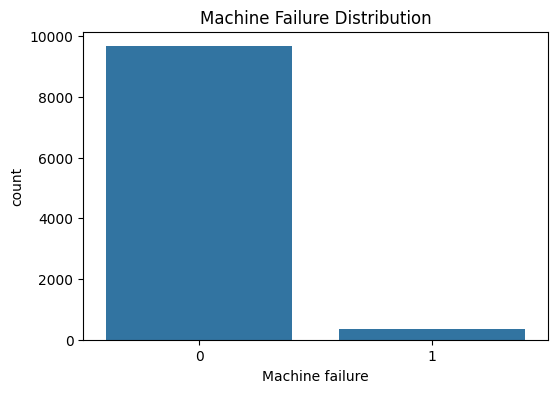

In [5]:
print(df['Machine failure'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x='Machine failure',
    data=df
)

plt.title("Machine Failure Distribution")

plt.show()

### Step 4 - Correlation Heatmap

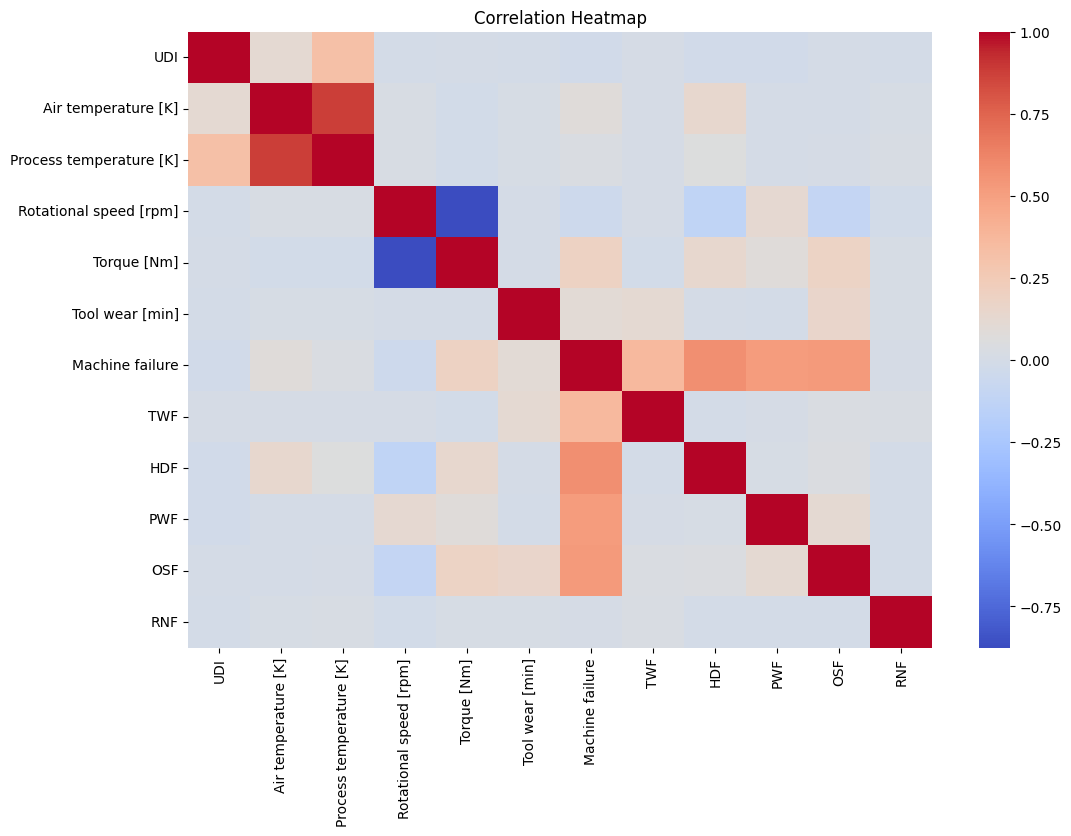

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Step 5 - Sensor Trend Visualizations

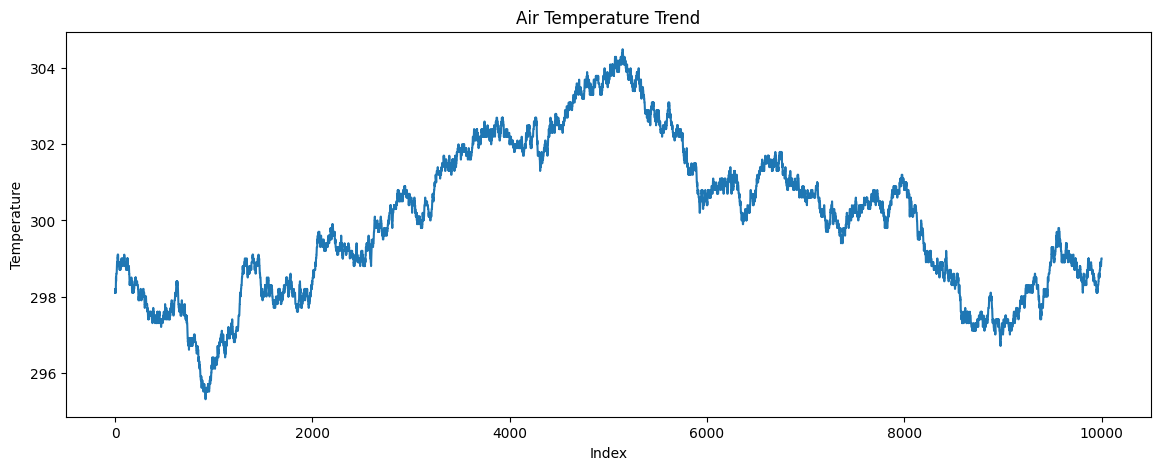

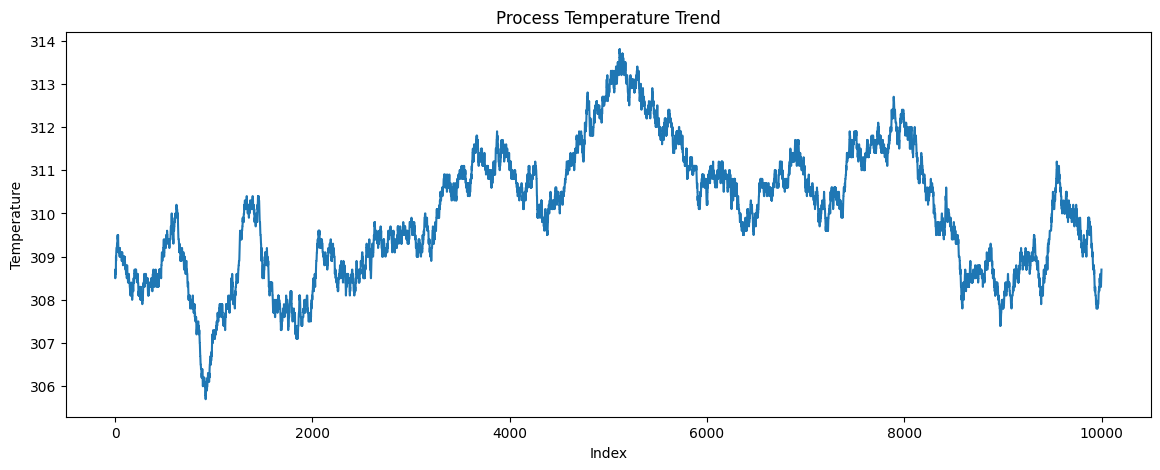

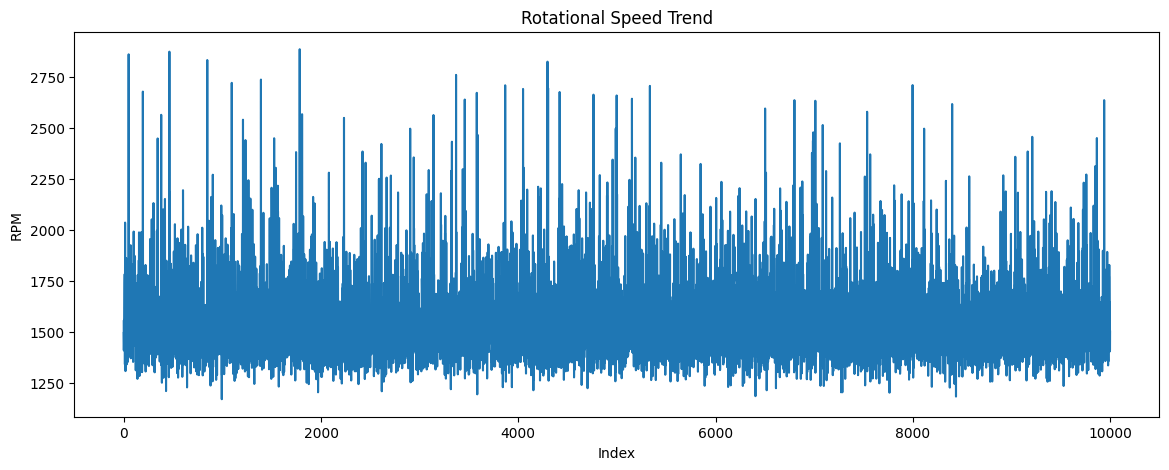

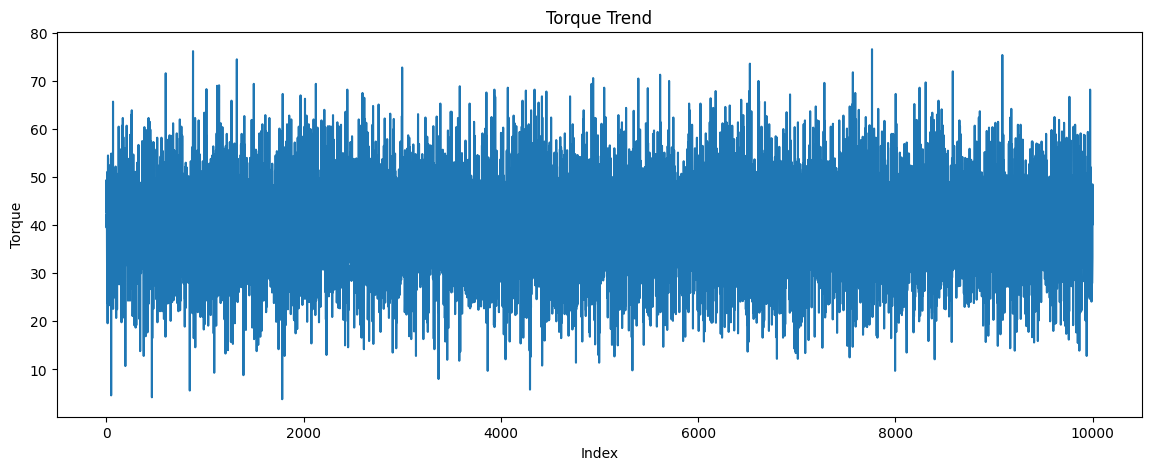

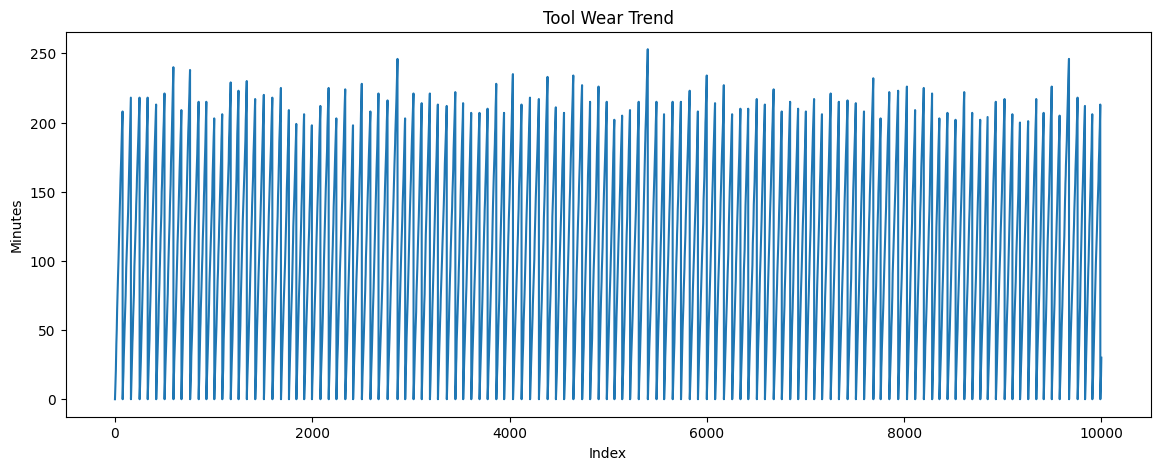

In [7]:
# Air Temperature
plt.figure(figsize=(14,5))
plt.plot(df['Air temperature [K]'])
plt.title("Air Temperature Trend")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.show()

# Process Temperature
plt.figure(figsize=(14,5))
plt.plot(df['Process temperature [K]'])
plt.title("Process Temperature Trend")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.show()

# Rotational Speed
plt.figure(figsize=(14,5))
plt.plot(df['Rotational speed [rpm]'])
plt.title("Rotational Speed Trend")
plt.xlabel("Index")
plt.ylabel("RPM")
plt.show()

# Torque
plt.figure(figsize=(14,5))
plt.plot(df['Torque [Nm]'])
plt.title("Torque Trend")
plt.xlabel("Index")
plt.ylabel("Torque")
plt.show()

# Tool Wear
plt.figure(figsize=(14,5))
plt.plot(df['Tool wear [min]'])
plt.title("Tool Wear Trend")
plt.xlabel("Index")
plt.ylabel("Minutes")
plt.show()

### Step 6 - Preprocessing

In [8]:
# Drop unnecessary columns
df.drop(
    ['UDI', 'Product ID'],
    axis=1,
    inplace=True
)

# Encode Machine Type
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Rename columns
df.columns = [
    col.lower()
    .replace(" ", "_")
    .replace("[", "")
    .replace("]", "")
    for col in df.columns
]
print(df.columns)
display(df.head())

Index(['type', 'air_temperature_k', 'process_temperature_k',
       'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure',
       'twf', 'hdf', 'pwf', 'osf', 'rnf'],
      dtype='str')


,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Step 7 - Save Cleaned Dataset

In [9]:
df.to_csv(
    r"C:\Zaalima Internship\Manufacturing - Predictive Maintenance System\data\raw\ai4i2020.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


### Step 8 - Rolling Window Features

In [10]:
# Rolling Mean Features
df['temp_roll_mean_6'] = (
    df['air_temperature_k']
    .rolling(window=6)
    .mean()
)
df['temp_roll_mean_12'] = (
    df['air_temperature_k']
    .rolling(window=12)
    .mean()
)

### Step 9 - Rolling Standard Deviation

In [11]:
df['torque_std_6'] = (
    df['torque_nm']
    .rolling(window=6)
    .std()
)

df['rpm_std_6'] = (
    df['rotational_speed_rpm']
    .rolling(window=6)
    .std()
)

### Step 10 - Exponential Moving Average (EMA)

In [12]:
df['temp_ema_6'] = (
    df['air_temperature_k']
    .ewm(span=6)
    .mean()
)

df['torque_ema_6'] = (
    df['torque_nm']
    .ewm(span=6)
    .mean()
)

### Step 11 - Lag Features

In [13]:
df['temp_lag1'] = (
    df['air_temperature_k']
    .shift(1)
)

df['temp_lag2'] = (
    df['air_temperature_k']
    .shift(2)
)

df['torque_lag1'] = (
    df['torque_nm']
    .shift(1)
)

### Step 12 - Delta Features

In [14]:
df['temp_delta'] = (
    df['air_temperature_k']
    - df['temp_lag1']
)

df['torque_delta'] = (
    df['torque_nm']
    - df['torque_lag1']
)

### Step 13 - Rate of Change Features

In [15]:
df['rpm_change'] = (
    df['rotational_speed_rpm']
    .pct_change()
)

df['torque_change'] = (
    df['torque_nm']
    .pct_change()
)

### Step 14 - Removing null values

In [16]:
df.dropna(inplace=True)

### Step 15 - Check new features

In [17]:
df.head()

,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_roll_mean_6,temp_roll_mean_12,torque_std_6,rpm_std_6,temp_ema_6,torque_ema_6,temp_lag1,temp_lag2,torque_lag1,temp_delta,torque_delta,rpm_change,torque_change
11,0,298.6,309.1,1423,44.3,29,0,0,0,0,0,0,298.333333,298.241667,8.721621,137.342880,298.394036,35.341168,298.4,298.5,23.9,0.2,20.4,-0.201459,0.853556
12,2,298.6,309.1,1339,51.1,34,0,0,0,0,0,0,298.416667,298.283333,10.767621,178.791965,298.453634,39.901143,298.6,298.4,44.3,0.0,6.8,-0.059030,0.153499
13,2,298.6,309.2,1742,30.0,37,0,0,0,0,0,0,298.500000,298.316667,10.780244,187.422162,298.495832,37.046556,298.6,298.6,51.1,0.0,-21.1,0.300971,-0.412916
14,1,298.6,309.2,2035,19.6,40,0,0,0,0,0,0,298.550000,298.358333,12.259432,255.448625,298.525787,32.029576,298.6,298.6,30.0,0.0,-10.4,0.168197,-0.346667
15,1,298.6,309.2,1542,48.4,42,0,0,0,0,0,0,298.566667,298.391667,13.429433,258.379114,298.547089,36.728415,298.6,298.6,19.6,0.0,28.8,-0.242260,1.469388


### Step 16 - Check Shape

In [18]:
df.shape

(9989, 25)

### Step 17 - Saving Feature Engineered Dataset

In [19]:
df.to_csv(
    r"C:\Zaalima Internship\Manufacturing - Predictive Maintenance System\data\raw\ai4i2020.csv",
    index=False
)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!


### Step 18 - Failure Horizion Labeliing & saving final dataset

In [21]:
# =========================
# FAILURE HORIZON LABELING
# =========================

# Create target column

df['failure_24h'] = 0

# Get indices where machine failure occurred

failure_indices = (
    df[df['machine_failure'] == 1]
    .index
)

# Label previous 24 rows as warning period

for idx in failure_indices:

    start = max(0, idx - 24)

    df.loc[start:idx, 'failure_24h'] = 1

# Check new target distribution

print(df['failure_24h'].value_counts())

# Preview dataset

display(df.head())

# Save final processed dataset

df.to_csv(
    r"C:\Zaalima Internship\Manufacturing - Predictive Maintenance System\data\raw\ai4i2020.csv",
    index=False
)

print("\nFinal dataset saved successfully!")

failure_24h
0    5356
1    4633
Name: count, dtype: int64


,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_roll_mean_6,temp_roll_mean_12,torque_std_6,rpm_std_6,temp_ema_6,torque_ema_6,temp_lag1,temp_lag2,torque_lag1,temp_delta,torque_delta,rpm_change,torque_change,failure_24h
11,0,298.6,309.1,1423,44.3,29,0,0,0,0,0,0,298.333333,298.241667,8.721621,137.342880,298.394036,35.341168,298.4,298.5,23.9,0.2,20.4,-0.201459,0.853556,0
12,2,298.6,309.1,1339,51.1,34,0,0,0,0,0,0,298.416667,298.283333,10.767621,178.791965,298.453634,39.901143,298.6,298.4,44.3,0.0,6.8,-0.059030,0.153499,0
13,2,298.6,309.2,1742,30.0,37,0,0,0,0,0,0,298.500000,298.316667,10.780244,187.422162,298.495832,37.046556,298.6,298.6,51.1,0.0,-21.1,0.300971,-0.412916,0
14,1,298.6,309.2,2035,19.6,40,0,0,0,0,0,0,298.550000,298.358333,12.259432,255.448625,298.525787,32.029576,298.6,298.6,30.0,0.0,-10.4,0.168197,-0.346667,0
15,1,298.6,309.2,1542,48.4,42,0,0,0,0,0,0,298.566667,298.391667,13.429433,258.379114,298.547089,36.728415,298.6,298.6,19.6,0.0,28.8,-0.242260,1.469388,0



Final dataset saved successfully!
